In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to your CSV with columns: model, condition, acc_continuous, ...
csv_path = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/v3/geogaze_model_predictions_resnet100_dice_12_3_25.csv"

df_long = pd.read_csv(csv_path)

# Quick sanity check
print(df_long.head())
print(df_long['condition'].value_counts())
print(df_long['model'].nunique(), "models")
print(df_long['acc_continuous'].describe())


         model condition         test_image                target  \
0  maskL_bc_bs     train  test_bc_bs_LR.png  test_left_c_mask.png   
1  maskL_bc_bs   spatial  test_bc_bc_LR.png  test_left_c_mask.png   
2  maskL_bc_bs   spatial  test_bs_bs_LR.png  test_left_s_mask.png   
3  maskL_bc_bs  featural  test_bc_bs_UD.png    test_up_c_mask.png   
4  maskL_bc_bs  featural  test_bs_bc_UD.png  test_down_c_mask.png   

              distractor                                         prediction  \
0  test_right_s_mask.png  test_bc_bs_LR__model=resnet50.a1_in1k_maskL_bc...   
1  test_right_c_mask.png  test_bc_bc_LR__model=resnet50.a1_in1k_maskL_bc...   
2  test_right_s_mask.png  test_bs_bs_LR__model=resnet50.a1_in1k_maskL_bc...   
3   test_down_s_mask.png  test_bc_bs_UD__model=resnet50.a1_in1k_maskL_bc...   
4     test_up_s_mask.png  test_bs_bc_UD__model=resnet50.a1_in1k_maskL_bc...   

   choice  acc_continuous  
0     NaN        0.537298  
1     NaN        0.169374  
2     NaN        0.500000 

In [5]:
# Conditions of interest
conds = ['train', 'spatial', 'featural', 'conflict']



# 1) Filter to desired conditions and models
df_filt = df_long.query("condition in @conds")

# 2) Per-model mean continuous accuracy per condition
per_model = (
    df_filt
    .groupby(['model', 'condition'], as_index=False)['acc_continuous']
    .mean()
    .rename(columns={'acc_continuous': 'acc'})
)

# Optional: convert to percent (0–100) for plotting like before
per_model['acc'] = per_model['acc'] * 100

print(per_model.head())


         model condition         acc
0  maskL_bc_bs  conflict  100.000000
1  maskL_bc_bs  featural   81.667966
2  maskL_bc_bs   spatial   33.468677
3  maskL_bc_bs     train   53.729757
4  maskL_bc_gc  conflict  100.000000


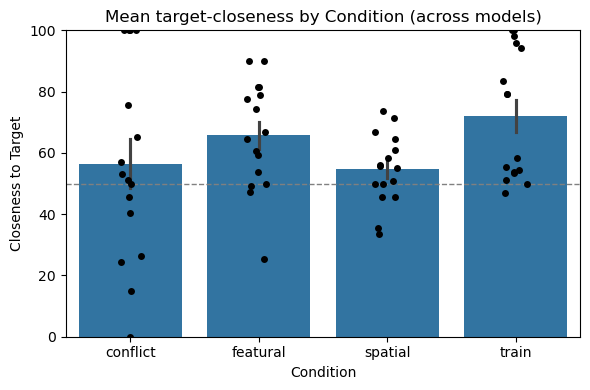

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Bars: mean score across models for each condition
ax = sns.barplot(
    data=per_model,
    x='condition', y='acc',
    errorbar='se'
)

# Dots: each model's score in that condition
sns.stripplot(
    data=per_model,
    x='condition', y='acc',
    color='black'
)

ax.set_title("Mean target-closeness by Condition (across models)")
ax.set_xlabel("Condition")
ax.set_ylabel("Closeness to Target")

plt.ylim(0, 100)

# ---- chance line (50%) ----
plt.axhline(y=50, linestyle='--', linewidth=1, color='gray')

plt.tight_layout()

# save as PNG
plt.savefig("resnet100_DICE_graph_acc.png", dpi=300)

plt.show()
